<a href="https://colab.research.google.com/github/Aditya-Gopal-Nayak/AI-Job-Preparation-Web-App/blob/main/customer_churn_prediction_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [1]:
import numpy as np
import pandas as pd
import math

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve

# Data Loading

In [2]:
df = pd.read_csv('customer_churn_dataset-training-master.csv')

# Dataset Overview

In [3]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [5]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [6]:
df.shape

(440833, 12)

# Data Cleaning

In [7]:
df.isnull().sum()

,0
CustomerID,1
Age,1
Gender,1
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Subscription Type,1
Contract Length,1
Total Spend,1


In [8]:
df[df.isnull().any(axis=1)]

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
199295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df.drop(['CustomerID'], axis=1, inplace=True)

In [10]:
df.dropna(inplace=True)

In [11]:
df.isnull().sum()

,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0
Last Interaction,0


In [12]:
to_int = ['Age','Support Calls', 'Churn']
df[to_int] = df[to_int].astype(int)

In [13]:
print(df[to_int].dtypes)

Age              int64
Support Calls    int64
Churn            int64
dtype: object


# Exploratory Data Analysis (EDA)

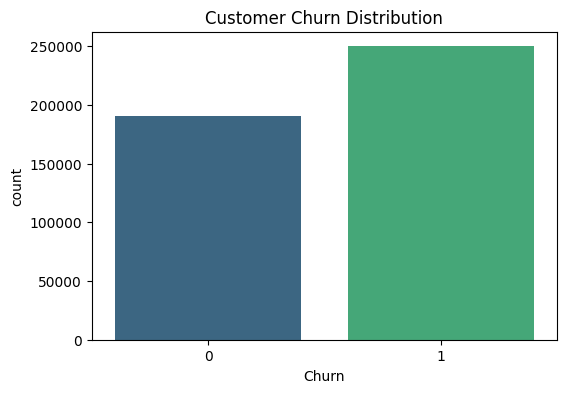

Churn
1    56.71072
0    43.28928
Name: proportion, dtype: float64


In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Customer Churn Distribution')
plt.show()

print(df['Churn'].value_counts(normalize=True) * 100)

Observation: The dataset shows a relatively balanced distribution. Approximately 56.7% of customers belong to the churn category, while 43.3% continue to use the service.

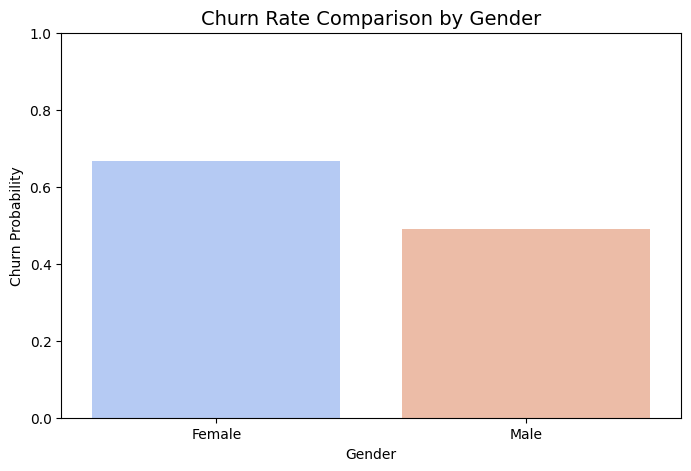

In [15]:
gender_churn_rate = df.groupby('Gender')['Churn'].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(x='Gender', y='Churn', data=gender_churn_rate, palette='coolwarm')
plt.title('Churn Rate Comparison by Gender', fontsize=14)
plt.ylabel('Churn Probability')
plt.xlabel('Gender')
plt.ylim(0, 1)
plt.show()

Observation: The churn probability for female customers is significantly higher than for male customers.

Analysis: Gender appears to be a strong predictive feature for churn. Further investigation into service experience or targeted campaigns for female customers might be necessary to understand this disparity.

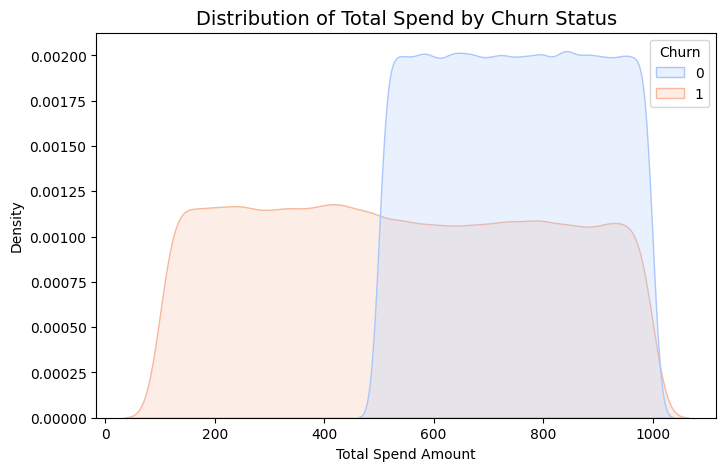

In [16]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='Total Spend', hue='Churn', fill=True, common_norm=False, palette='coolwarm')

plt.title('Distribution of Total Spend by Churn Status', fontsize=14)
plt.xlabel('Total Spend Amount')
plt.ylabel('Density')
plt.show()

Observation: There is a very sharp correlation between 'Total Spend' and Churn.

Analysis: Customers who spend less than 500 units show a very high tendency to churn, whereas those spending above 500 units are much more likely to stay.

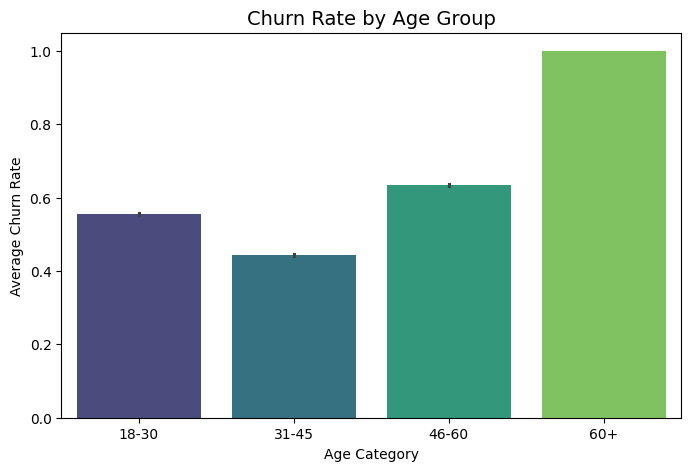

In [17]:
bins = [18, 30, 45, 60, 100]
labels = ['18-30', '31-45', '46-60', '60+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
plt.figure(figsize=(8, 5))
sns.barplot(x='Age_Group', y='Churn', data=df, palette='viridis')
plt.title('Churn Rate by Age Group', fontsize=14)
plt.xlabel('Age Category')
plt.ylabel('Average Churn Rate')
plt.show()

Observation: Churn rate tends to increase with age.

Analysis: Remarkably, almost all customers in the 60+ age group have churned. The 31-45 age group appears to be the most loyal segment with the lowest churn rate. This suggests a potential service or accessibility issue for the older demographic.

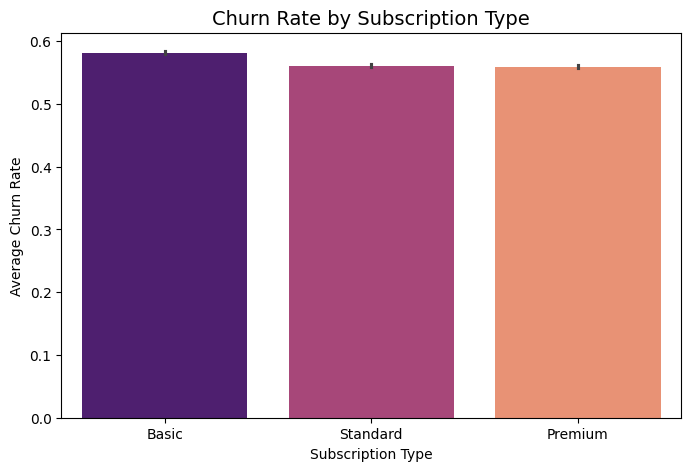

In [18]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Subscription Type', y='Churn', data=df, palette='magma', order=['Basic', 'Standard', 'Premium'])

plt.title('Churn Rate by Subscription Type', fontsize=14)
plt.xlabel('Subscription Type')
plt.ylabel('Average Churn Rate')
plt.show()

Observation: Churn rates are remarkably similar across all three subscription types.

Analysis: Subscription type alone is not a strong predictor of churn. Customers tend to leave at similar rates regardless of their plan level.

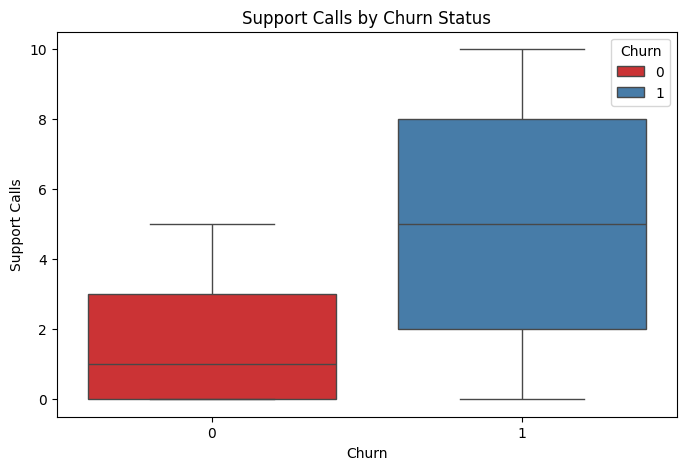

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='Support Calls', data=df, hue='Churn', palette='Set1')
plt.title("Support Calls by Churn Status")
plt.show()

Observation: It is evident that customers who churned (1) made significantly more support calls compared to those who stayed (0).

Analysis: The median number of support calls for churned customers is 5, whereas it is around 1 for loyal customers.

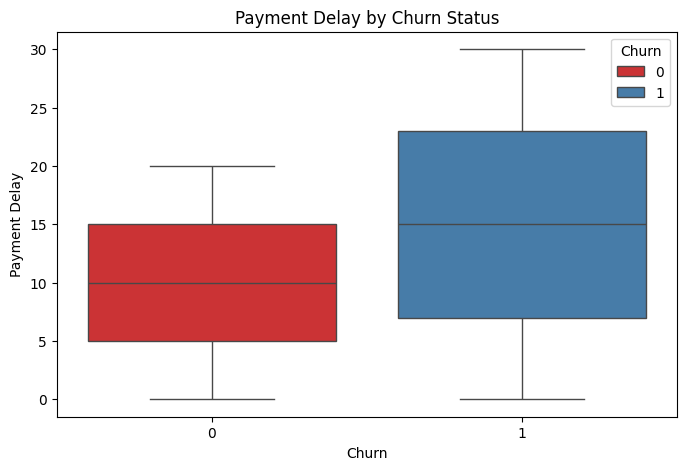

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='Payment Delay', data=df, hue='Churn', palette='Set1')
plt.title('Payment Delay by Churn Status')
plt.show()

Observation: Customers who churned tend to have longer payment delays.

Analysis: The median payment delay for churned customers (1) is approximately 15 days, compared to 10 days for loyal customers.

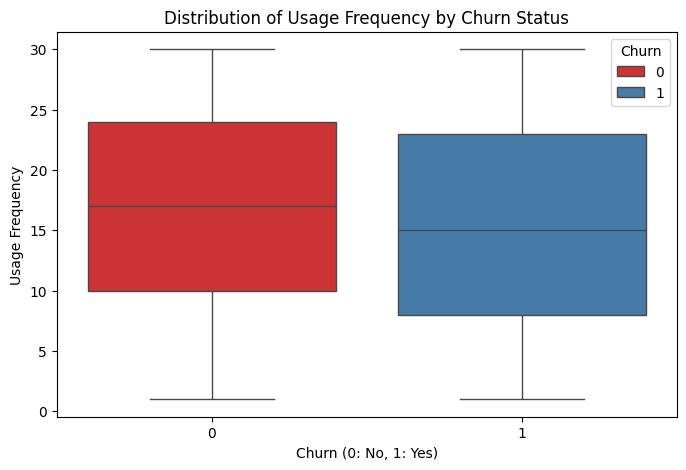

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='Usage Frequency', data=df, hue="Churn", palette="Set1")
plt.title('Distribution of Usage Frequency by Churn Status')
plt.xlabel('Churn (0: No, 1: Yes)',)
plt.ylabel('Usage Frequency',)
plt.show()

Observation: While there isn't a massive visual gap in Usage Frequency between the two groups, churned customers show slightly lower usage levels.

Analysis: Although the medians are relatively close, the lower quartile (Q1) for churned customers is notably lower.

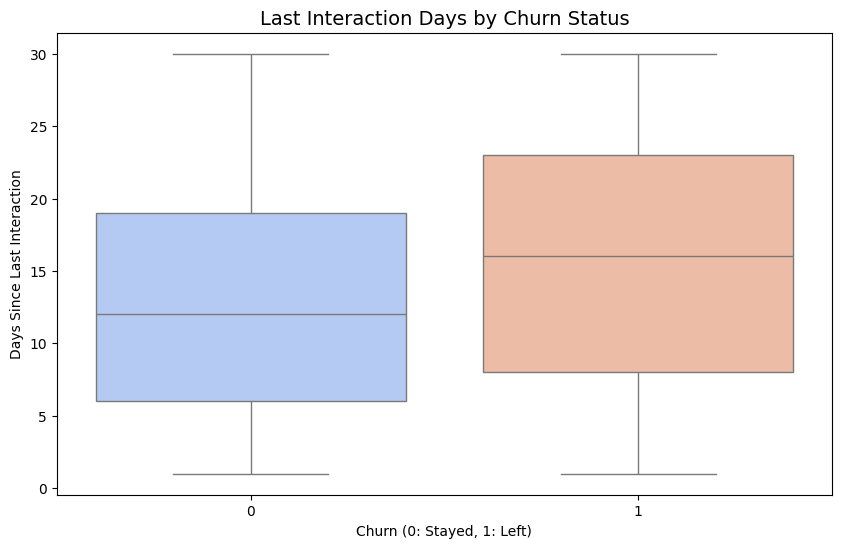

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='Last Interaction', data=df, palette='coolwarm')

plt.title('Last Interaction Days by Churn Status', fontsize=14)
plt.xlabel('Churn (0: Stayed, 1: Left)')
plt.ylabel('Days Since Last Interaction')
plt.show()

Observation: The median time since the last interaction is higher for churned customers compared to loyal ones.

Analysis: The median for the churned group (1) is around 16 days, while for the stayed group (0) it is around 12 days.

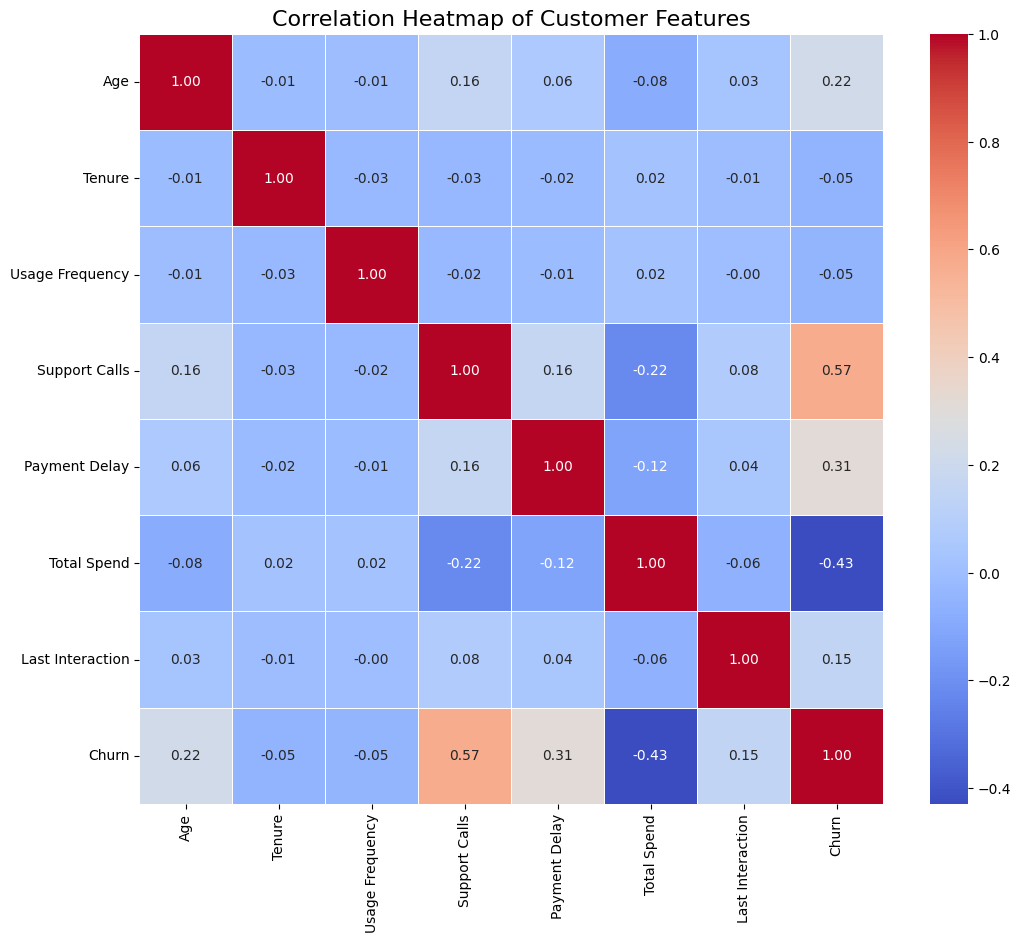

In [23]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Customer Features', fontsize=16)
plt.show()

Observation: According to the heatmap, the features with the strongest correlation to "Churn" are:

Support Calls (0.57): Strongest positive correlation. As support calls increase, the likelihood of churn rises significantly.

Total Spend (-0.43): Strong negative correlation. Higher spending leads to a lower churn probability.

Payment Delay (0.31): Positive correlation. Longer payment delays increase the churn risk.

# Feature Engineering & Data Preprocessing

In [24]:
# Drop columns that won't help the model predict churn
df_model = df.drop(columns=['Age_Group'], errors='ignore')

In [25]:
# Encoding Gender: Male -> 0, Female -> 1
df_model['Gender'] = df_model['Gender'].map({'Male': 0, 'Female': 1})

In [26]:
# One-Hot Encoding for multi-category columns
df_model = pd.get_dummies(df_model, columns=['Subscription Type', 'Contract Length'], drop_first=True, dtype=int)

# Bakalım yeni sütunlar nasıl görünüyor
print(df_model.head())

   Age  Gender  Tenure  Usage Frequency  Support Calls  Payment Delay  \
0   30       1    39.0             14.0              5           18.0   
1   65       1    49.0              1.0             10            8.0   
2   55       1    14.0              4.0              6           18.0   
3   58       0    38.0             21.0              7            7.0   
4   23       0    32.0             20.0              5            8.0   

   Total Spend  Last Interaction  Churn  Subscription Type_Premium  \
0        932.0              17.0      1                          0   
1        557.0               6.0      1                          0   
2        185.0               3.0      1                          0   
3        396.0              29.0      1                          0   
4        617.0              20.0      1                          0   

   Subscription Type_Standard  Contract Length_Monthly  \
0                           1                        0   
1                       

In [27]:
X = df_model.drop(columns=['Churn'])
y = df_model['Churn'].astype(int)

print(X.columns.tolist())
print(y.name)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train: {X_train.shape[0]}")
print(f"X_test: {X_test.shape[0]}")

['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Subscription Type_Premium', 'Subscription Type_Standard', 'Contract Length_Monthly', 'Contract Length_Quarterly']
Churn
X_train: 352665
X_test: 88167


# Feature Scaling

In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
# Imports
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Base Models

lr_model = LogisticRegression(
    max_iter=500,
    C=0.5
)

rf_model = RandomForestClassifier(
    n_estimators=80,
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

xgb_model = XGBClassifier(
    n_estimators=60,
    max_depth=3,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

# Hybrid Ensemble

hybrid_model = VotingClassifier(
    estimators=[
        ('lr', lr_model),
        ('rf', rf_model),
        ('xgb', xgb_model)
    ],
    voting='soft'
)

# Train

hybrid_model.fit(X_train_scaled, y_train)

# Prediction

y_pred = hybrid_model.predict(X_test_scaled)

y_prob = hybrid_model.predict_proba(X_test_scaled)[:, 1]

# Metrics

acc = accuracy_score(y_test, y_pred)

prec = precision_score(y_test, y_pred)

rec = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

# Print Results

print("Hybrid Ensemble Results")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Hybrid Ensemble Results
Accuracy  : 0.9781
Precision : 0.9965
Recall    : 0.9650
F1 Score  : 0.9805
ROC AUC   : 0.9956

Classification Report
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     38063
           1       1.00      0.96      0.98     50104

    accuracy                           0.98     88167
   macro avg       0.98      0.98      0.98     88167
weighted avg       0.98      0.98      0.98     88167

